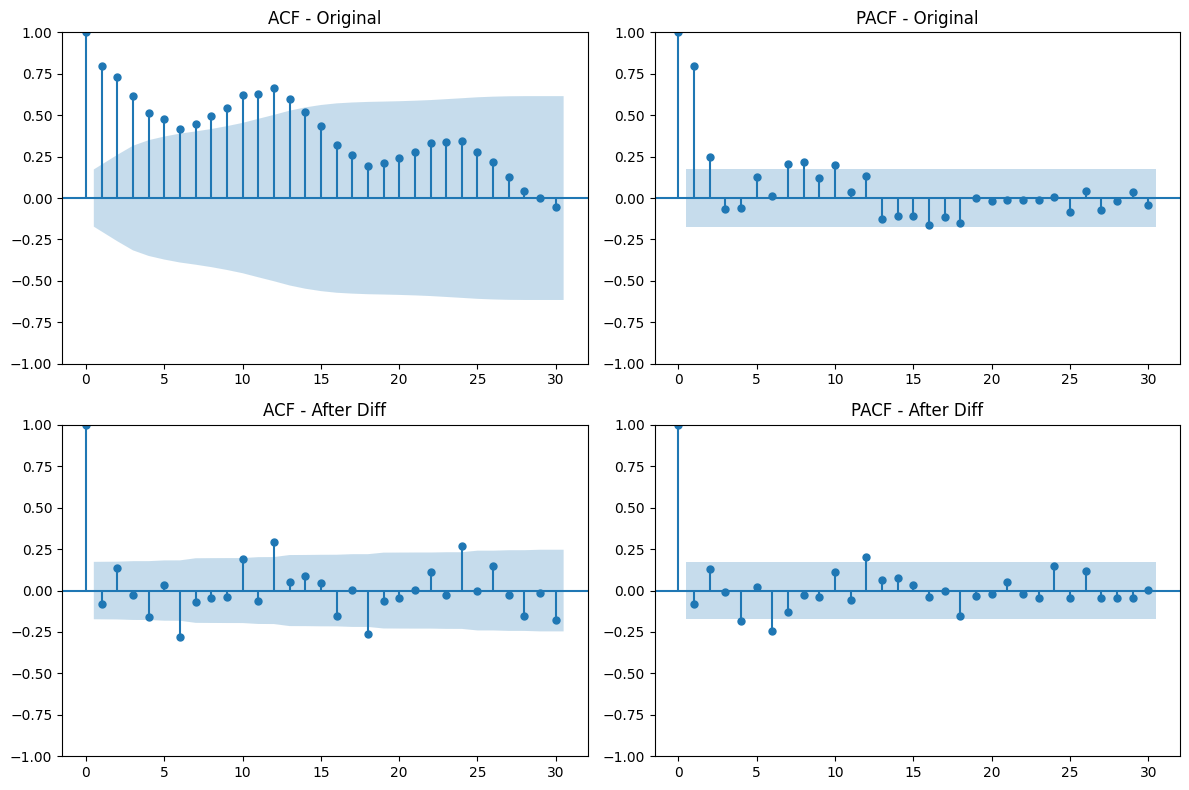

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

combined = pd.read_csv('../data/boston_crime_combined.csv', low_memory=False)

# aggregate by month
combined['OCCURRED_ON_DATE'] = pd.to_datetime(combined['OCCURRED_ON_DATE'])
monthly = combined.groupby(['YEAR', 'MONTH']).size().reset_index(name='count')
monthly['date'] = pd.to_datetime(monthly[['YEAR', 'MONTH']].assign(DAY=1))
monthly = monthly.sort_values('date').set_index('date')

# first difference to remove trend
monthly['count_diff'] = monthly['count'].diff()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

plot_acf(monthly['count'].dropna(), lags=30, ax=axes[0, 0], title='ACF - Original')
plot_pacf(monthly['count'].dropna(), lags=30, ax=axes[0, 1], title='PACF - Original')

plot_acf(monthly['count_diff'].dropna(), lags=30, ax=axes[1, 0], title='ACF - After Diff')
plot_pacf(monthly['count_diff'].dropna(), lags=30, ax=axes[1, 1], title='PACF - After Diff')

plt.tight_layout()
plt.show()

In [3]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# fit SARIMA(1,1,1)(1,1,1,12)
model = SARIMAX(monthly['count'], order=(1,1,1), seasonal_order=(1,1,1,12))
result = model.fit()

print(result.summary())

/Users/zouli/opt/anaconda3/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/zouli/opt/anaconda3/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
 This problem is unconstrained.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  7.00292D+00    |proj g|=  1.55275D-01

At iterate    5    f=  6.94512D+00    |proj g|=  2.52764D-02

At iterate   10    f=  6.93964D+00    |proj g|=  3.74399D-03

At iterate   15    f=  6.93897D+00    |proj g|=  2.34118D-03

At iterate   20    f=  6.93885D+00    |proj g|=  2.40019D-03

At iterate   25    f=  6.93852D+00    |proj g|=  1.01242D-03

At iterate   30    f=  6.93839D+00    |proj g|=  5.25732D-04

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nac

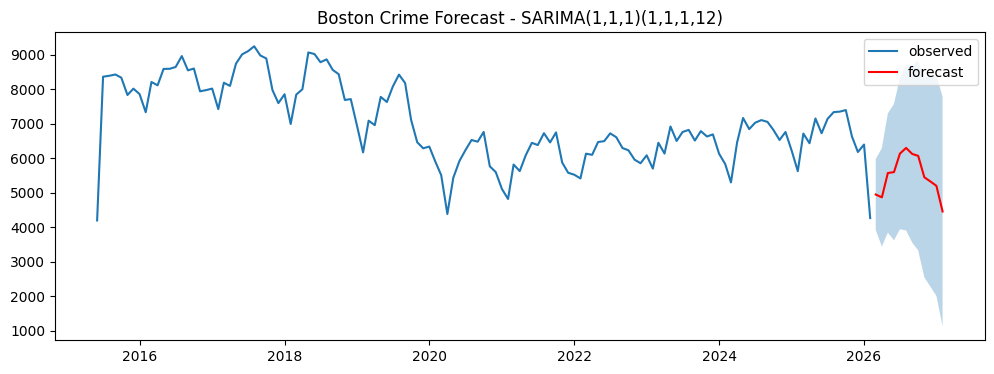

In [4]:
# forecast next 12 months
forecast = result.get_forecast(steps=12)
pred = forecast.predicted_mean
ci = forecast.conf_int()

plt.figure(figsize=(12, 4))
plt.plot(monthly['count'], label='observed')
plt.plot(pred, label='forecast', color='red')
plt.fill_between(ci.index, ci.iloc[:, 0], ci.iloc[:, 1], alpha=0.3)
plt.title('Boston Crime Forecast - SARIMA(1,1,1)(1,1,1,12)')
plt.legend()
plt.show()